# 02. AC Stark landscape and local addressing

局域寻址(local addressing)的 AC Stark 物理与参数扫描:从能级图与 AC Stark 标定,到 Rabi/sweep 动力学,再到参数扫描与 adiabaticity 诊断。三能级 `{0,1,r}` 模型用 `level_structure("01r", ryd_level=70)` + `DigitalAnalogProtocol`(S06 映射 g→`0`、e→`1`、r→`r`),AC Stark shift/scatter 用 inline 的 Grimm D1+D2 模型(PH02)。

## 0. Notebook setup

准备路径、Matplotlib 与新的 `ryd_gate` API(`Register` / `RydbergSystem` / `level_structure` / `simulate` / `DigitalAnalogProtocol`)。AC Stark shift/scatter 的标定模型(原 `ryd_gate.physics.compute_shift_scatter`)已从包中删除,这里 inline 完整可执行公式并按论文值标定。

In [ ]:
from pathlib import Path
import os
import sys

os.environ.setdefault("JAX_PLATFORMS", "cpu")

HERE = Path.cwd().resolve()
if HERE.name == "notebooks":
    REPO_ROOT = HERE.parents[1]
elif HERE.name == "scripts":
    REPO_ROOT = HERE.parent
else:
    REPO_ROOT = HERE
os.chdir(REPO_ROOT)

src_path = REPO_ROOT / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
from scipy.constants import pi
from matplotlib.colors import LogNorm, SymLogNorm

from ryd_gate import Register, RydbergSystem, level_structure, simulate
from ryd_gate.protocols import DigitalAnalogProtocol, blackman_pulse

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})
print(f"Repo root: {REPO_ROOT}")

In [ ]:
# =====================================================================
# PH02: inlined AC-Stark shift & scattering model (Grimm D1 + D2).
#
# The Manovitz-style scalar+vector light-shift/scattering model used to
# live in ryd_gate.physics.compute_shift_scatter; it was removed from the
# package, so the full executable formula is reproduced here.  Following
# Grimm, Weidemueller & Ovchinnikov (2000), the dipole shift on an alkali
# ground-state sub-level |F, m_F> in a far-detuned field is
#
#     U ~ (2 + P g_F m_F)/3 * 1/Delta_D2  +  (1 - P g_F m_F)/3 * 1/Delta_D1
#
# with P the laser helicity; we bundle pol = P * g_F * m_F (default 0 =
# linear pol -> the pure-scalar 2/3, 1/3 D2/D1 weights).  Calibrated to the
# Manovitz et al. measurement: -12.2 MHz shift and 35 Hz scatter at 784 nm,
# 160 uW over a 1 um waist, linear polarization.
# =====================================================================
from arc import Rubidium87
from scipy.constants import c as C_LIGHT

_atom_d = Rubidium87()
FREQ_D2 = _atom_d.getTransitionFrequency(5, 0, 0.5, 5, 1, 1.5)   # Hz
FREQ_D1 = _atom_d.getTransitionFrequency(5, 0, 0.5, 5, 1, 0.5)   # Hz
LAMBDA_D2 = C_LIGHT / FREQ_D2 * 1e9   # nm
LAMBDA_D1 = C_LIGHT / FREQ_D1 * 1e9   # nm
GAMMA_D2 = 2 * pi * 6.065e6           # rad/s
GAMMA_D1 = 2 * pi * 5.746e6           # rad/s
G_F_5S12_F2 = 0.5                     # Lande g-factor, 5S1/2 F=2

LAMBDA_PAPER = 784.0                  # nm   calibration wavelength
CALIBRATION_SHIFT_HZ = -12.2e6        # Hz   at 160 uW
CALIBRATION_SCATTER_HZ = 35.0         # Hz   at 160 uW
POWER_REF_UW = 160.0                  # uW   reference power


def _raw_shift_and_scatter(wavelengths_nm, pol=0.0):
    """Grimm D1+D2 shift and scatter (arb. units) with scalar+vector weights."""
    wl = np.asarray(wavelengths_nm, dtype=float)
    omega = 2 * pi * C_LIGHT / (wl * 1e-9)
    shift = np.zeros_like(omega)
    scatter = np.zeros_like(omega)
    weight_D2 = (2.0 + pol) / 3.0
    weight_D1 = (1.0 - pol) / 3.0
    for omega_line, Gamma_line, w in [
        (2 * pi * FREQ_D2, GAMMA_D2, weight_D2),
        (2 * pi * FREQ_D1, GAMMA_D1, weight_D1),
    ]:
        Dr = omega_line - omega
        Dc = omega_line + omega
        shift += w * Gamma_line / omega_line**3 * (1.0 / Dr + 1.0 / Dc)
        scatter += (w * Gamma_line**2 / omega_line**3
                    * (omega / omega_line)**3 * (1.0 / Dr + 1.0 / Dc)**2)
    return shift, scatter


# Calibrate in the linear-pol (pol=0) limit against the paper values at 784 nm.
_s784, _sc784 = _raw_shift_and_scatter(LAMBDA_PAPER, pol=0.0)
_SHIFT_CAL = float(CALIBRATION_SHIFT_HZ / _s784)
_SCATTER_CAL = float(CALIBRATION_SCATTER_HZ / _sc784)


def compute_shift_scatter(wavelengths_nm, pol=0.0):
    """Calibrated AC-Stark shift (Hz) and scattering rate (Hz); scalar or array."""
    s, sc = _raw_shift_and_scatter(wavelengths_nm, pol=pol)
    return s * _SHIFT_CAL, sc * _SCATTER_CAL


# Computational-basis population helper.  S06 mapping: g -> |0>, e -> |1>, r -> |r>.
_LABEL = {"g": "0", "e": "1", "r": "r"}


def basis_pop(result, config):
    """Population |<config|psi(t_gate)>|^2 for a string like 'gr' (g/e/r per site)."""
    return float(abs(result.amplitude([_LABEL[ch] for ch in config])) ** 2)


print(f"D1 = {LAMBDA_D1:.3f} nm,  D2 = {LAMBDA_D2:.3f} nm")
_s0, _sc0 = compute_shift_scatter(LAMBDA_PAPER)
print(f"calibrated @784nm/160uW:  shift = {float(_s0)/1e6:.2f} MHz,  scatter = {float(_sc0):.1f} Hz")

## 1. Two-atom local-addressing energy levels

画 `|gg>`、`|gr>`、`|rg>` 及 adiabatic branches 随 detuning 的变化。local addressing 的核心不是"关掉一个原子",而是用局域 detuning 移动 avoided crossing、使目标态沿不同 branch 演化。

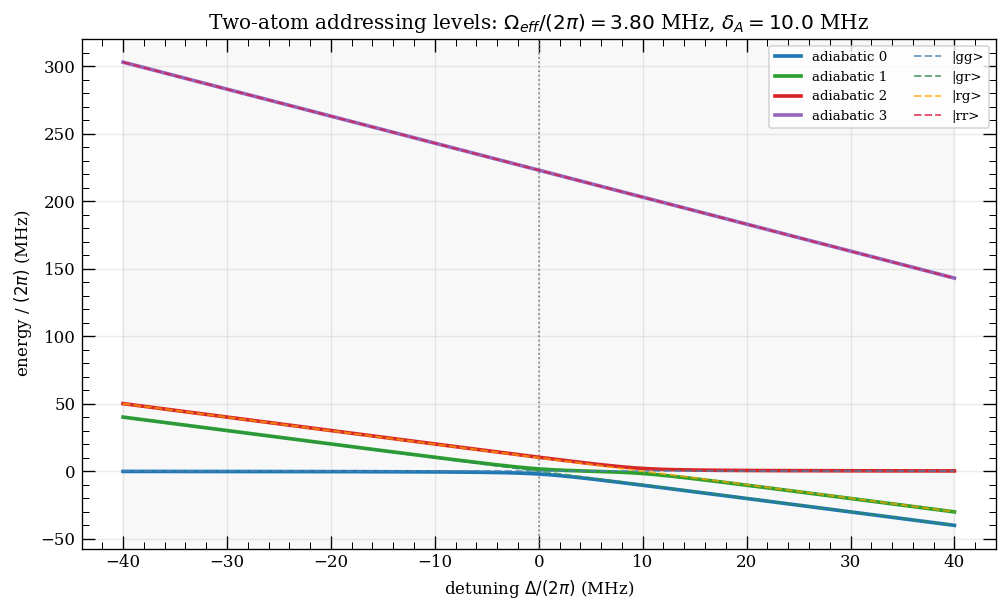

In [3]:
O420 = 135.0      # MHz
O1013 = 135.0     # MHz
Dint = 2.4        # GHz
dA = 10.0         # MHz, local pinning detuning
d420 = 0.0        # MHz
Vr = 213.0        # MHz
sweep_half = 40.0 # MHz
current_delta = 0.0

Oeff = O420 * O1013 / (2 * Dint * 1e3)
dtot = dA + d420
Delta2 = np.linspace(-sweep_half, sweep_half, 500)

# 直接按脚本写 Hamiltonian batch，不额外封装函数。
H = np.zeros((len(Delta2), 4, 4))
h = Oeff / 2
H[:, 0, 1] = H[:, 1, 0] = h
H[:, 0, 2] = H[:, 2, 0] = h
H[:, 1, 3] = H[:, 3, 1] = h
H[:, 2, 3] = H[:, 3, 2] = h
H[:, 1, 1] = -Delta2
H[:, 2, 2] = -Delta2 + dtot
H[:, 3, 3] = -2 * Delta2 + dtot + Vr
adiab = np.linalg.eigvalsh(H)

E_gg = np.zeros_like(Delta2)
E_gr = -Delta2
E_rg = -Delta2 + dtot
E_rr = -2 * Delta2 + dtot + Vr

fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.axvspan(-sweep_half, sweep_half, color="lightgray", alpha=0.15)
ax.axvline(current_delta, color="gray", ls=":", lw=1)
for j, color in enumerate(["#1f77b4", "#2ca02c", "#d62728", "#9467bd"]):
    ax.plot(Delta2, adiab[:, j], lw=2.2, color=color, label=f"adiabatic {j}")
for y, label, color in [(E_gg, "|gg>", "steelblue"), (E_gr, "|gr>", "seagreen"), (E_rg, "|rg>", "orange"), (E_rr, "|rr>", "crimson")]:
    ax.plot(Delta2, y, "--", lw=1.2, color=color, alpha=0.7, label=label)
ax.set_xlabel(r"detuning $\Delta/(2\pi)$ (MHz)")
ax.set_ylabel(r"energy / $(2\pi)$ (MHz)")
ax.set_title(rf"Two-atom addressing levels: $\Omega_{{eff}}/(2\pi)={Oeff:.2f}$ MHz, $\delta_A={dtot:.1f}$ MHz")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()


## 2. AC Stark wavelength-power landscape

`compute_shift_scatter` 取参考功率下的 light shift 与 scattering,按功率线性缩放成二维图:shift 在 D lines 间变号、scattering 近共振急升。目标是找"够大 Stark shift 但 scattering 可接受"的 wavelength/power 区域。

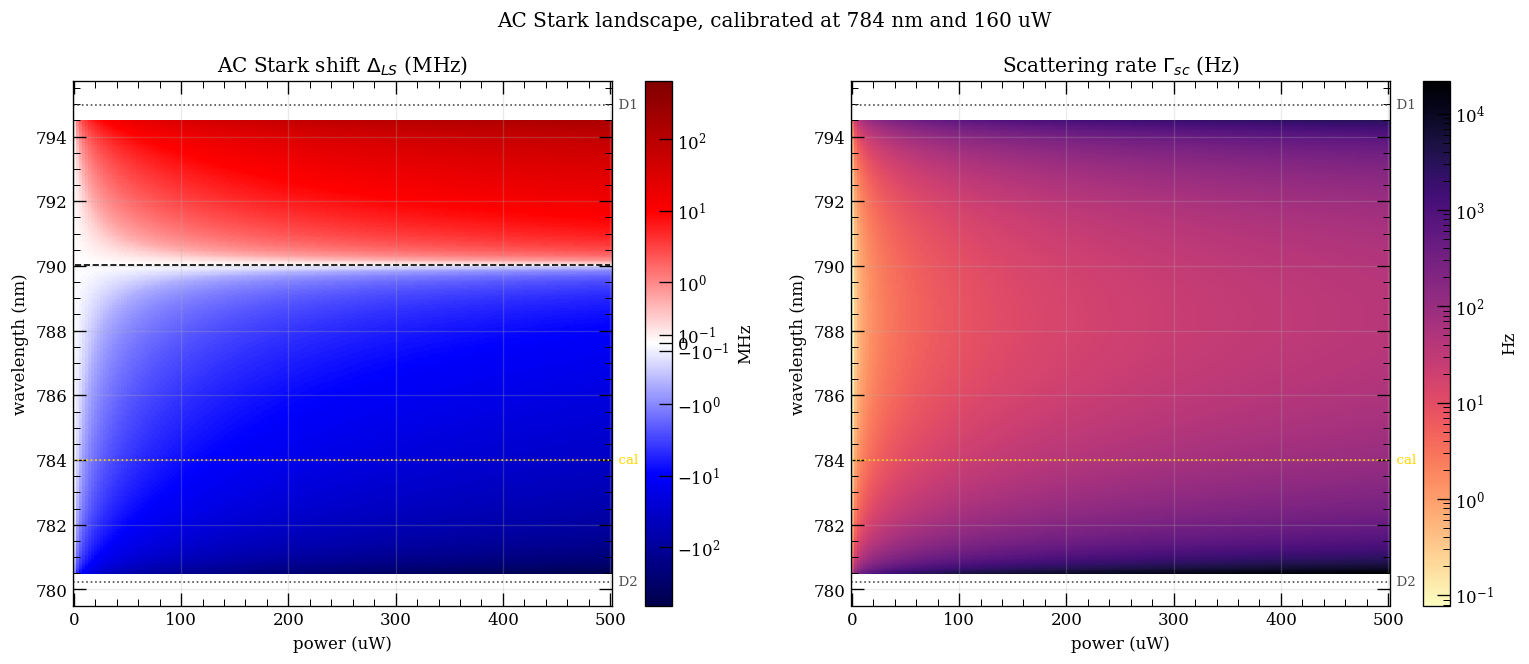

In [4]:
wl_nm = np.linspace(780.5, 794.5, 360)
power_uw = np.linspace(1.0, 500.0, 180)

shift_ref_hz, scatter_ref_hz = compute_shift_scatter(wl_nm)
scale = power_uw / POWER_REF_UW
shift_mhz = shift_ref_hz[:, None] * scale[None, :] / 1e6
scatter_hz = scatter_ref_hz[:, None] * scale[None, :]

fig, (ax_s, ax_sc) = plt.subplots(1, 2, figsize=(13, 5.6))
lin_thr = 0.5
vmax = float(np.nanmax(np.abs(shift_mhz)))
im_s = ax_s.pcolormesh(
    power_uw, wl_nm, shift_mhz, cmap="seismic",
    norm=SymLogNorm(linthresh=lin_thr, linscale=0.5, vmin=-vmax, vmax=vmax, base=10),
    shading="auto",
)
try:
    ax_s.contour(power_uw, wl_nm, shift_mhz, levels=[0.0], colors="k", linewidths=1.0, linestyles="--")
except ValueError:
    pass
for wl, label, color in [(LAMBDA_D1, "D1", "0.3"), (LAMBDA_D2, "D2", "0.3"), (LAMBDA_PAPER, "cal", "gold")]:
    ax_s.axhline(wl, color=color, lw=1, ls=":")
    ax_sc.axhline(wl, color=color, lw=1, ls=":")
    ax_s.text(power_uw[-1], wl, "  " + label, va="center", fontsize=8, color=color)
    ax_sc.text(power_uw[-1], wl, "  " + label, va="center", fontsize=8, color=color)
ax_s.set_title(r"AC Stark shift $\Delta_{LS}$ (MHz)")
ax_s.set_xlabel("power (uW)")
ax_s.set_ylabel("wavelength (nm)")
fig.colorbar(im_s, ax=ax_s, label="MHz")

sc_floor = max(1e-3, float(np.nanmin(scatter_hz[scatter_hz > 0])))
im_sc = ax_sc.pcolormesh(
    power_uw, wl_nm, np.clip(scatter_hz, sc_floor, None), cmap="magma_r",
    norm=LogNorm(vmin=sc_floor, vmax=float(np.nanmax(scatter_hz))), shading="auto",
)
ax_sc.set_title(r"Scattering rate $\Gamma_{sc}$ (Hz)")
ax_sc.set_xlabel("power (uW)")
ax_sc.set_ylabel("wavelength (nm)")
fig.colorbar(im_sc, ax=ax_sc, label="Hz")
fig.suptitle(rf"AC Stark landscape, calibrated at {LAMBDA_PAPER:.0f} nm and {POWER_REF_UW:.0f} uW")
fig.tight_layout()
plt.show()


## 3. AC Stark one-dimensional figures of merit

profile / scatter-per-shift / required-shift:不同 power 的 profile 形状相同、只随 power 线性缩放;`Γ_sc/|Δ_LS|` 是 power-independent 的 wavelength FOM——把"要多少光强"与"wavelength 本身干不干净"分开。

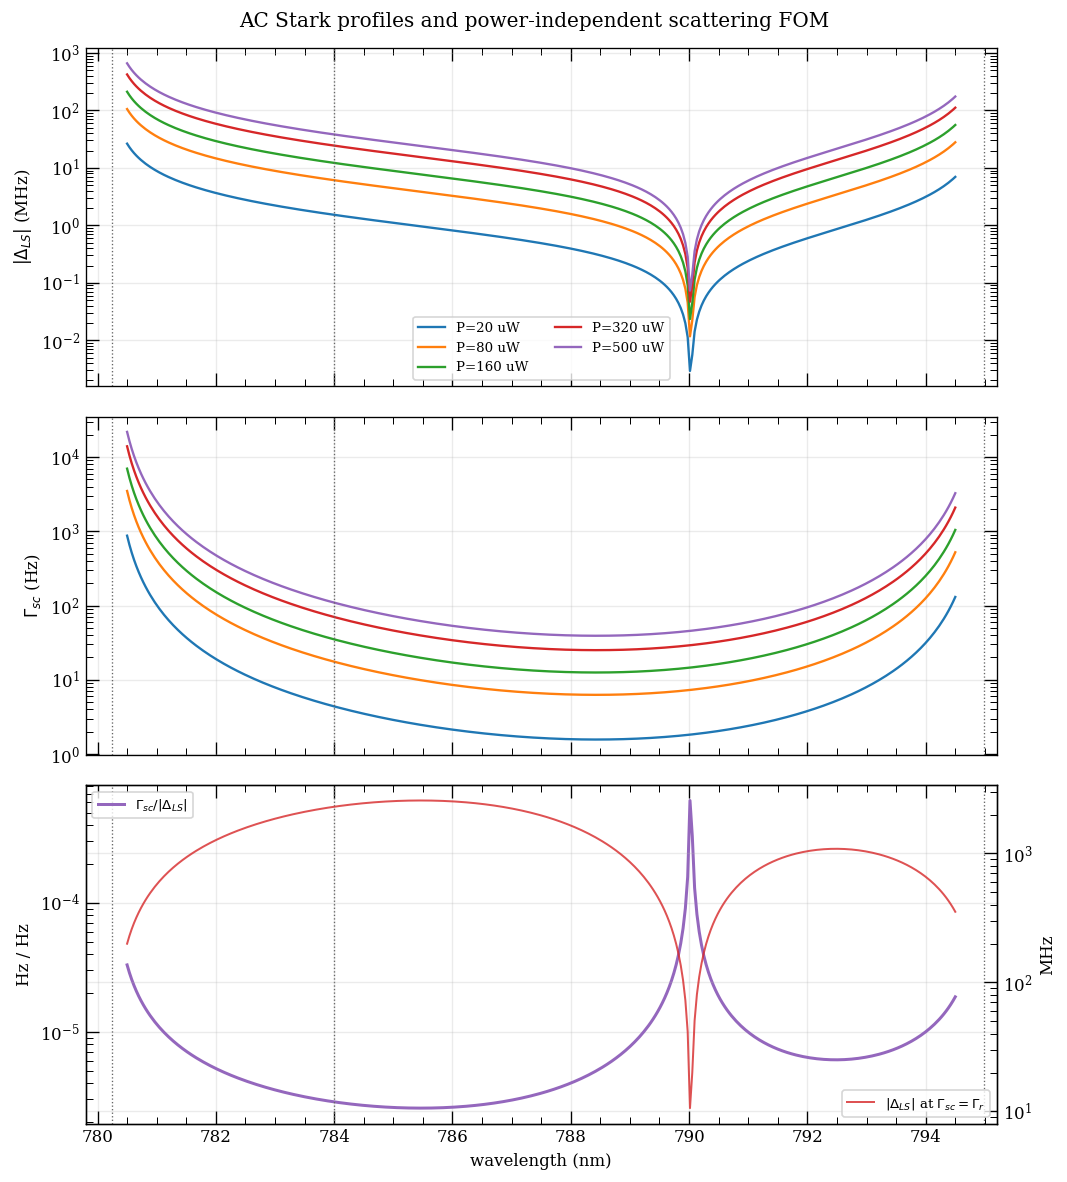

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)
profile_powers = [20, 80, 160, 320, 500]
for P in profile_powers:
    shift_hz, scatter_hz_1d = compute_shift_scatter(wl_nm)
    s_mhz = shift_hz * (P / POWER_REF_UW) / 1e6
    sc_hz = scatter_hz_1d * (P / POWER_REF_UW)
    axes[0].plot(wl_nm, np.abs(s_mhz), lw=1.4, label=f"P={P} uW")
    axes[1].plot(wl_nm, sc_hz, lw=1.4, label=f"P={P} uW")

ratio = scatter_ref_hz / np.maximum(np.abs(shift_ref_hz), 1e-300)
gamma_ryd_hz = 1.0 / 151.55e-6
shift_match_mhz = gamma_ryd_hz / ratio / 1e6
axes[2].plot(wl_nm, ratio, lw=1.8, color="tab:purple", label=r"$\Gamma_{sc}/|\Delta_{LS}|$")
ax2 = axes[2].twinx()
ax2.plot(wl_nm, shift_match_mhz, lw=1.2, color="tab:red", alpha=0.8, label=r"$|\Delta_{LS}|$ at $\Gamma_{sc}=\Gamma_r$")

for ax in axes:
    ax.set_yscale("log")
    for line in (LAMBDA_D1, LAMBDA_D2, LAMBDA_PAPER):
        ax.axvline(line, color="0.4", lw=0.8, ls=":")
axes[0].set_ylabel(r"$|\Delta_{LS}|$ (MHz)")
axes[1].set_ylabel(r"$\Gamma_{sc}$ (Hz)")
axes[2].set_ylabel(r"Hz / Hz")
axes[2].set_xlabel("wavelength (nm)")
ax2.set_yscale("log")
ax2.set_ylabel("MHz")
axes[0].legend(ncol=2, fontsize=8)
axes[2].legend(loc="upper left", fontsize=8)
ax2.legend(loc="lower right", fontsize=8)
fig.suptitle("AC Stark profiles and power-independent scattering FOM")
fig.tight_layout()
plt.show()


## 4. Polarization and vector-Stark sensitivity

少量 circular contamination 会移动 tune-out、改变 vector sensitivity;在 784–786 nm window 内选 `|∂Δ/∂pol|/|Δ|` 较小的 wavelength。local addressing 不只要低 scattering,还要对 polarization impurity 不敏感。

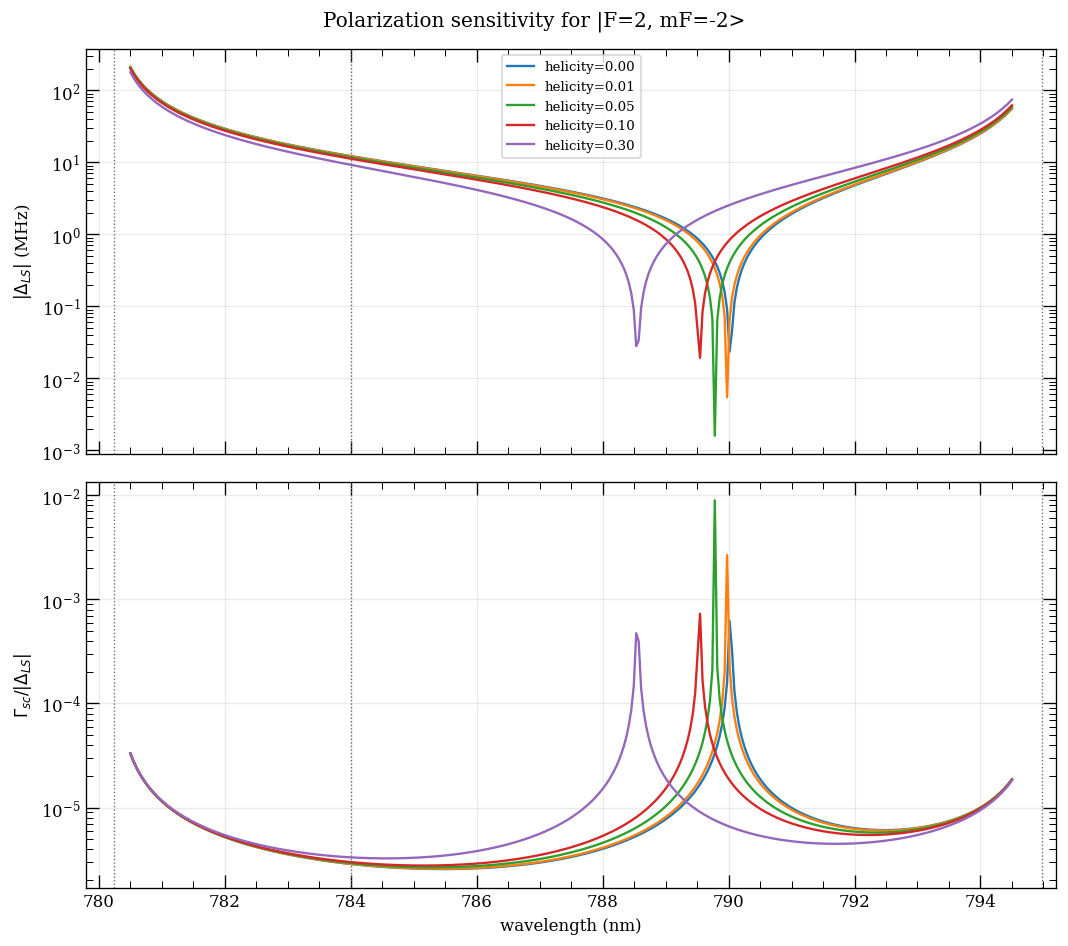

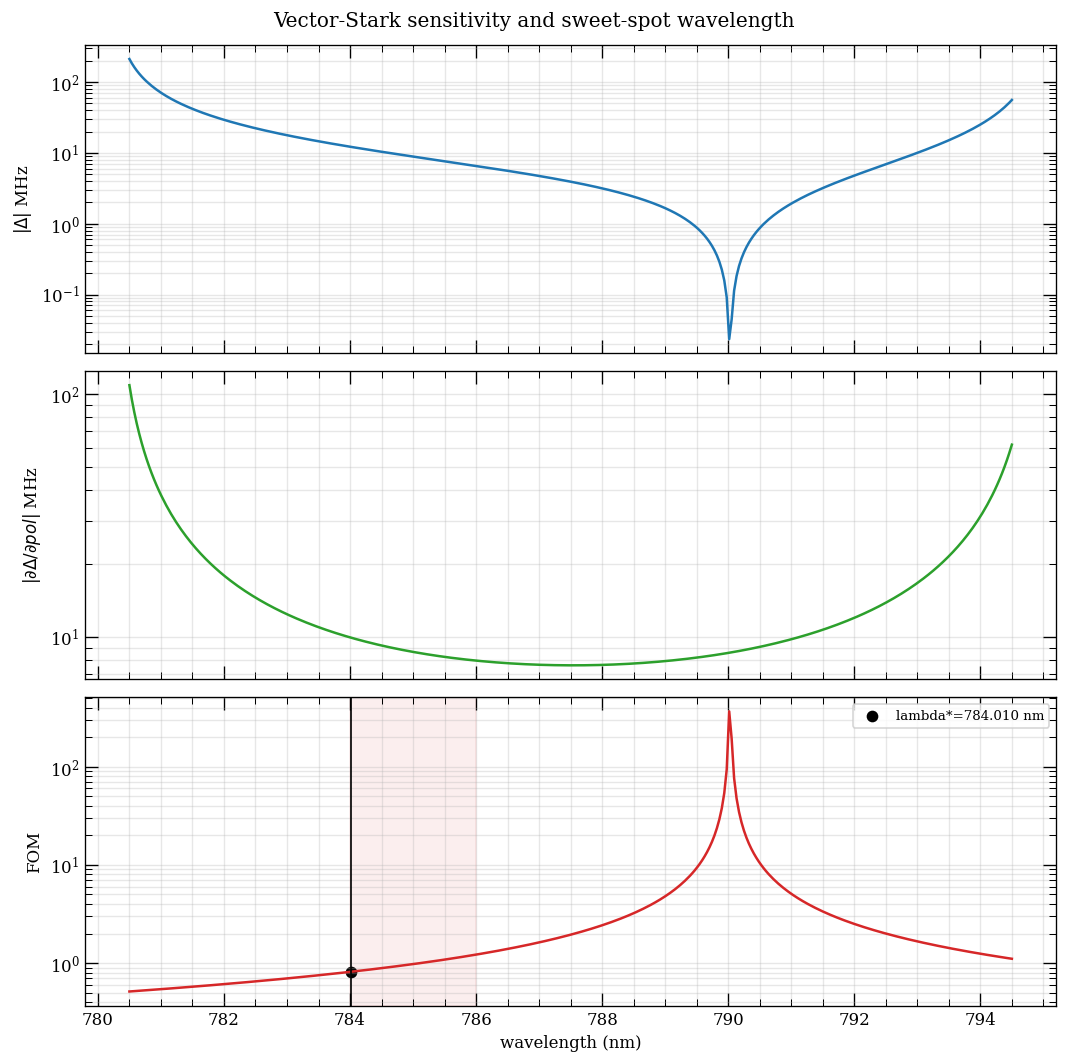

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
helicities = [0.0, 0.01, 0.05, 0.10, 0.30]
m_F = -2
for P_hel in helicities:
    pol = P_hel * G_F_5S12_F2 * m_F
    s_hz, sc_hz = compute_shift_scatter(wl_nm, pol=pol)
    axes[0].plot(wl_nm, np.abs(s_hz) / 1e6, lw=1.4, label=f"helicity={P_hel:.2f}")
    axes[1].plot(wl_nm, sc_hz / np.maximum(np.abs(s_hz), 1e-300), lw=1.4, label=f"helicity={P_hel:.2f}")
for ax in axes:
    ax.set_yscale("log")
    for line in (LAMBDA_D1, LAMBDA_D2, LAMBDA_PAPER):
        ax.axvline(line, color="0.4", lw=0.8, ls=":")
axes[0].set_ylabel(r"$|\Delta_{LS}|$ (MHz)")
axes[1].set_ylabel(r"$\Gamma_{sc}/|\Delta_{LS}|$")
axes[1].set_xlabel("wavelength (nm)")
axes[0].legend(fontsize=8)
fig.suptitle("Polarization sensitivity for |F=2, mF=-2>")
fig.tight_layout()
plt.show()

shift0_hz, _ = compute_shift_scatter(wl_nm, pol=0.0)
eps = 1e-3
shift_p, _ = compute_shift_scatter(wl_nm, pol=+eps)
shift_m, _ = compute_shift_scatter(wl_nm, pol=-eps)
dshift_dpol_mhz = (shift_p - shift_m) / (2 * eps) / 1e6
abs_scalar_mhz = np.abs(shift0_hz) / 1e6
fom = np.abs(dshift_dpol_mhz) / np.maximum(abs_scalar_mhz, 1e-300)
window = (wl_nm >= 784.0) & (wl_nm <= 786.0)
i_opt = int(np.argmin(np.where(window, fom, np.inf)))

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
axes[0].plot(wl_nm, abs_scalar_mhz, lw=1.5)
axes[1].plot(wl_nm, np.abs(dshift_dpol_mhz), lw=1.5, color="tab:green")
axes[2].plot(wl_nm, fom, lw=1.5, color="tab:red")
axes[2].axvspan(784, 786, color="tab:red", alpha=0.08)
axes[2].axvline(wl_nm[i_opt], color="k", lw=1.0)
axes[2].scatter([wl_nm[i_opt]], [fom[i_opt]], color="k", label=f"lambda*={wl_nm[i_opt]:.3f} nm")
for ax in axes:
    ax.set_yscale("log")
    ax.grid(alpha=0.3, which="both")
axes[0].set_ylabel(r"$|\Delta|$ MHz")
axes[1].set_ylabel(r"$|\partial\Delta/\partial pol|$ MHz")
axes[2].set_ylabel("FOM")
axes[2].set_xlabel("wavelength (nm)")
axes[2].legend(fontsize=8)
fig.suptitle("Vector-Stark sensitivity and sweet-spot wavelength")
fig.tight_layout()
plt.show()


## 5. Rabi dynamics: blockade vs addressed atom

比较 global resonant drive 与 atom A 被局域 detuning pin 住时的 Rabi:global 下 blockade 使两原子只能集体振荡;addressed 下 atom A 基本不进 Rydberg、atom B 自由振荡。

In [ ]:
# ---- Analog {0,1,r} model parameters (replaces the deleted analog_3 preset) ----
# S06 mapping: |0> = ground g, |1> = intermediate e (far detuned), |r> = Rydberg.
# These scales lived on the old preset; here they are explicit and visible.
#
# NOTE ON SCALE: the hardware intermediate detuning is ~2*pi*9.1 GHz.  The exact
# ODE backend integrates the FULL 3-level state vector, so it must resolve the
# ~Delta phase of the (small) |1> amplitude -- at 9.1 GHz a single 1.5 us sweep
# takes minutes.  For this smoke-scale run we lower Delta to 2*pi*1 GHz and scale
# the single-photon Rabis so the two-photon effective rate rabi_eff is unchanged;
# every formula below is identical and Delta >> omega still holds (adiabatic
# elimination valid).  Restore Delta=2*pi*9.1e9, omega=2*pi*491e6 for production.
ryd_level  = 70
Delta      = 2 * pi * 1.0e9      # intermediate detuning on |1> (rad/s); see note
omega_420  = 2 * pi * 163e6      # single-photon |0>-|1> Rabi (rad/s)
omega_1013 = 2 * pi * 163e6      # single-photon |1>-|r> Rabi (rad/s)
rabi_eff   = omega_420 * omega_1013 / (2 * abs(Delta))   # two-photon effective Rabi
time_scale = 2 * pi / rabi_eff                            # 2*pi / rabi_eff
t_rise     = 20e-9                                        # Blackman rise/fall
ac_stark_peak = omega_420 ** 2 / (4 * abs(Delta))         # |0> light shift at full 420 power

# Looser exact-ODE tolerances for the smoke-scale run (default is 1e-8 / 1e-12).
OPT = {"rtol": 1e-7, "atol": 1e-9}

print(f"Delta/2pi      = {Delta/(2*pi)/1e9:.3f} GHz")
print(f"omega_420/2pi  = {omega_420/(2*pi)/1e6:.1f} MHz   omega_1013/2pi = {omega_1013/(2*pi)/1e6:.1f} MHz")
print(f"rabi_eff/2pi   = {rabi_eff/(2*pi)/1e6:.3f} MHz    time_scale = {time_scale*1e9:.1f} ns")
print(f"AC-Stark peak/2pi = {ac_stark_peak/(2*pi)/1e6:.3f} MHz")

LS  = level_structure("01r", ryd_level=ryd_level)
REG = Register.chain(2, spacing_um=3.0)


def make_system(protocol):
    return RydbergSystem(level_structure=LS, register=REG, protocol=protocol)


def analog_protocol(t_gate, *, delta_start=0.0, delta_end=0.0,
                    blackman=True, compensate=False, addressing=None, n_sites=2):
    """DigitalAnalogProtocol for the {0,1,r} analog two-photon model.

        coupling_10 = 0.5*omega_420*env(t)    # |1><0| leg 1 (Blackman-enveloped)
        coupling_r1 = 0.5*omega_1013          # |r><1| leg 2 (constant)
        energy_1    = Delta                   # intermediate detuning on |1>
        energy_r(t) = -delta_sweep(t) + AC-Stark feed-forward + per-site addressing

    The two-photon detuning is swept linearly from ``delta_start`` to ``delta_end``
    on |r>.  ``addressing`` is a ``{site: local_detuning_rad_s}`` map (a focused
    beam light-shifting an atom's |0>-|r> resonance out of the global sweep).
    ``compensate`` adds +ac_stark_peak*env(t)^2 (the AC-Stark shift formula) to
    |r> as feed-forward.  ``energy_1`` is kept fixed at ``Delta`` (the
    |delta| << Delta correction is ~0.4% and negligible).
    """
    chirp = (delta_end - delta_start) / t_gate
    addr = np.zeros(n_sites)
    for i, d in (addressing or {}).items():
        addr[i] = d

    def env(t):
        return blackman_pulse(t, t_rise, t_gate) if blackman else 1.0

    def energy_r(t):
        base = -(delta_start + chirp * t)
        if compensate:
            base += ac_stark_peak * env(t) ** 2
        return base * np.ones(n_sites) + addr

    return DigitalAnalogProtocol(
        t_gate_s=t_gate,
        coupling_10_rad_s=lambda t: 0.5 * omega_420 * env(t),
        coupling_r1_rad_s=lambda t: 0.5 * omega_1013,
        energy_1_rad_s=lambda t: Delta,
        energy_r_rad_s=energy_r,
    )

In [ ]:
# Global drive vs. local addressing.  Blockade lives on |r> (isotropic C6 at 3 um);
# |0> and |1> do not interact, so a resonant global two-photon drive drives the
# collective |gg> <-> (|gr>+|rg>)/sqrt(2) oscillation at sqrt(2)*rabi_eff, while a
# large local detuning on atom A pins it in |g> and lets atom B Rabi freely.
LOCAL_DETUNING = 2 * pi * 50e6     # local pin on atom A (rad/s)
t_rabi = 2 * time_scale
t_eval = np.linspace(0, t_rabi, 150)

sys_free = make_system(analog_protocol(t_rabi, blackman=False))
sys_addr = make_system(analog_protocol(t_rabi, blackman=False, addressing={0: LOCAL_DETUNING}))
of = sys_free.observables
obs = {"n_r_0": of.n("r", 0), "n_r_1": of.n("r", 1)}

res_free = simulate(sys_free, ["0", "0"], t_eval=t_eval, observables=obs, backend_options=OPT)
res_addr = simulate(sys_addr, ["0", "0"], t_eval=t_eval, observables=obs, backend_options=OPT)

fig, axes = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True)
axes[0].plot(res_free.times * 1e6, res_free.expectation("n_r_0"), label=r"$P_r^A$")
axes[0].plot(res_free.times * 1e6, res_free.expectation("n_r_1"), "--", label=r"$P_r^B$")
axes[0].set_title("Global excitation: blockade active (collective oscillation)")
axes[1].plot(res_addr.times * 1e6, res_addr.expectation("n_r_0"), label=r"$P_r^A$")
axes[1].plot(res_addr.times * 1e6, res_addr.expectation("n_r_1"), "--", label=r"$P_r^B$")
axes[1].set_title("Atom A addressed: atom B Rabi oscillates")
for ax in axes:
    ax.set_ylabel("population")
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
axes[1].set_xlabel("time (us)")
fig.tight_layout()
plt.show()

## 6. Adiabatic sweep and AC-Stark feed-forward

两原子的 blockade-constrained adiabatic passage:blockade 禁止 `|rr>`,所以 `|gg>` 被扫入单激发 W 态 `(|gr>+|rg>)/√2`。Blackman-enveloped 420 leg 在 `|0>` 上引入 `ac_stark_peak·env(t)²` 的 AC-Stark shift 并扭曲 sweep;feed-forward(`compensate=True`)把这个公式直接加到 `|r>` 上作补偿。

在 `T_GATE=1.2 µs` 时补偿把残余 `|gg>` defect 从 ~6% 压到 ~2%、W 态转移从 ~0.93 提到 ~0.97——sweep fidelity 依赖相位/频率补偿,而非只看静态 detuning 大小。补偿量正是可见的 AC-Stark 公式 `ac_stark_peak·env(t)²`;收益大小随 envelope/sweep 时长而变(1013 leg 不带包络,微分 light shift 大部分是静态偏移)。

In [ ]:
# Adiabatic two-photon detuning sweep (delta_start -> delta_end on |r>), with the
# 420 leg Blackman-enveloped.  Blockade forbids |rr>, so |gg> is dragged into the
# single-excitation W-state (|gr>+|rg>)/sqrt(2).  ``compensate`` adds the AC-Stark
# shift formula (+ac_stark_peak*env^2) on |r> as feed-forward; at T_GATE=1.2 us it
# roughly halves the residual |gg> defect (~6% -> ~2%).
DELTA_START = -2 * pi * 40e6
DELTA_END = 2 * pi * 40e6
T_GATE = 1.2e-6
t_eval = np.linspace(0, T_GATE, 200)

sys_raw = make_system(analog_protocol(T_GATE, delta_start=DELTA_START, delta_end=DELTA_END,
                                      blackman=True, compensate=False))
sys_comp = make_system(analog_protocol(T_GATE, delta_start=DELTA_START, delta_end=DELTA_END,
                                       blackman=True, compensate=True))
of = sys_raw.observables
obs = {"n_r_0": of.n("r", 0), "n_r_1": of.n("r", 1),
       "sum_n_r": of.n("r", 0) + of.n("r", 1)}
res_raw = simulate(sys_raw, ["0", "0"], t_eval=t_eval, observables=obs, backend_options=OPT)
res_comp = simulate(sys_comp, ["0", "0"], t_eval=t_eval, observables=obs, backend_options=OPT)

keys = ["gg", "gr", "rg", "rr"]
pops_raw = {k: basis_pop(res_raw, k) for k in keys}
pops_comp = {k: basis_pop(res_comp, k) for k in keys}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, (res, pops_final, title) in enumerate(
    [(res_raw, pops_raw, "no compensation"), (res_comp, pops_comp, "AC-Stark feed-forward")]
):
    ax = axes[0, col]
    ax.plot(res.times * 1e6, res.expectation("n_r_0"), label=r"$P_r^A$")
    ax.plot(res.times * 1e6, res.expectation("n_r_1"), "--", label=r"$P_r^B$")
    ax.plot(res.times * 1e6, res.expectation("sum_n_r") / 2, ":", color="gray", label=r"$\langle n_r\rangle/2$")
    ax.set_title(title)
    ax.set_xlabel("time (us)")
    ax.set_ylabel("population")
    ax.legend(fontsize=8)

    ax = axes[1, col]
    vals = [pops_final[k] for k in keys]
    ax.bar(range(len(keys)), vals, color=["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728"], edgecolor="black")
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels([f"|{k}>" for k in keys])
    ax.set_ylim(0, 1.1)
    ax.set_title("final populations")
    for j, v in enumerate(vals):
        ax.text(j, v + 0.02, f"{v:.2f}", ha="center", fontsize=9)
fig.suptitle(rf"AC Stark feed-forward: peak shift = {ac_stark_peak/(2*pi)/1e6:.2f} MHz")
fig.tight_layout()
plt.show()

## 7. Landau-Zener diagnostic for the sweep

扫 sweep time、拟合 `P_defect = exp(-C Ω_eff²/v)`:足够宽 window 下拟合常数 `C` 接近理论量级——判断 sweep error 是 diabatic LZ transition,还是有限边界/错误 crossing。

In [ ]:
from scipy.optimize import curve_fit

# Scan the sweep time and fit the diabatic defect P_gg = exp(-C * Omega_eff^2 / v),
# v = delta_range / t_gate.  Square (non-Blackman) sweep so the sweep rate is well
# defined.  (Smoke scale: 8 sweep times, ~0.05-0.6 us.)
Omega_eff = rabi_eff
ds = -20 * Omega_eff
de = 20 * Omega_eff
delta_range = de - ds
t_gates = np.logspace(np.log10(0.05e-6), np.log10(0.6e-6), 8)
sweep_rates = delta_range / t_gates
p_defect = np.empty(len(t_gates))
p_af = np.empty(len(t_gates))

for i, t_g in enumerate(t_gates):
    sys_lz = make_system(analog_protocol(t_g, delta_start=ds, delta_end=de, blackman=False))
    result = simulate(sys_lz, ["0", "0"], backend_options=OPT)
    p_defect[i] = basis_pop(result, "gg")
    p_af[i] = basis_pop(result, "gr") + basis_pop(result, "rg")

mask = (p_defect > 0.005) & (p_defect < 0.95)
if mask.sum() >= 3:
    popt, _ = curve_fit(lambda v, C: np.exp(np.clip(-C * Omega_eff**2 / v, -500, 0)),
                        sweep_rates[mask], p_defect[mask], p0=[np.pi])
    C_fit = float(popt[0])
else:
    C_fit = np.pi

v_fine = np.logspace(np.log10(sweep_rates.min()), np.log10(sweep_rates.max()), 200)
t_fine_us = delta_range / v_fine * 1e6
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(t_gates * 1e6, p_defect, "ko-", ms=4, label="simulation")
ax.plot(t_fine_us, np.exp(np.clip(-C_fit * Omega_eff**2 / v_fine, -500, 0)), "r-", label=f"fit C={C_fit:.2f}")
ax.plot(t_fine_us, np.exp(np.clip(-np.pi * Omega_eff**2 / v_fine, -500, 0)), "b--", label="theory C=pi")
ax.set_xscale("log")
ax.set_xlabel("T_gate (us)")
ax.set_ylabel(r"$P_{defect}=P_{gg}$")
ax.set_title("Two-atom Landau-Zener defect probability")
ax.legend()
fig.tight_layout()
plt.show()

## 8. Single-qubit wavelength-power scan

单原子模型:atom A 被强 detuning pin 住,virtual atom B 只感受 Gaussian tail `η δ_A` 并完成 adiabatic passage。total cost heatmap 在 not-pinned / crosstalk / scattering 间折中。默认读 `results/ac_stark_addressing/optimization_grids/addressing_1q_grid.csv`,否则 `RUN_SINGLE_QUBIT_SCAN=True` 跑小 scan。

In [ ]:
RUN_SINGLE_QUBIT_SCAN = False
single_csv = REPO_ROOT / "results" / "ac_stark_addressing" / "optimization_grids" / "addressing_1q_grid.csv"
GRID_1Q_DTYPE = [
    ("wl", float), ("power_uw", float), ("delta_A_mhz", float), ("delta_B_mhz", float), ("scatter_A_hz", float),
    ("P_g_A", float), ("P_e_A", float), ("P_r_A", float), ("P_g_B", float), ("P_e_B", float), ("P_r_B", float),
    ("not_pinned", float), ("leakage", float), ("crosstalk", float), ("scatter_penalty", float), ("total_cost", float),
    ("delta_A_over_Omega", float),
]

grid_1q = None
if single_csv.exists():
    raw = np.loadtxt(single_csv, delimiter=",", dtype=float)
    if raw.ndim == 1:
        raw = raw.reshape(1, -1)
    grid_1q = np.empty(raw.shape[0], dtype=GRID_1Q_DTYPE)
    for i, name in enumerate(grid_1q.dtype.names):
        grid_1q[name] = raw[:, i]
    print(f"Loaded {single_csv}")
elif RUN_SINGLE_QUBIT_SCAN:
    # Single atom: the addressing beam AC-Stark shifts atom A by delta_A (from
    # compute_shift_scatter); the virtual "unaddressed" atom B feels only the
    # Gaussian tail eta*delta_A and should complete the adiabatic passage to |r>.
    REG_1q = Register.chain(1, spacing_um=3.0)
    distance_um, waist_um = 4.0, 1.0
    eta = np.exp(-2 * (distance_um / waist_um) ** 2)
    t_gate_1q = 1.0e-6
    DS_1q, DE_1q = -2 * pi * 40e6, 2 * pi * 40e6
    wls = np.linspace(781.0, 786.0, 6)
    powers = np.linspace(160.0, 500.0, 6)
    grid_1q = np.empty(len(wls) * len(powers), dtype=GRID_1Q_DTYPE)
    idx = 0
    for wl in wls:
        s_ref, sc_ref = compute_shift_scatter(wl)
        for power in powers:
            scale = power / POWER_REF_UW
            delta_A = 2 * pi * float(s_ref) * scale
            delta_B = eta * delta_A
            scatter_A = float(sc_ref) * scale
            proto_A = analog_protocol(t_gate_1q, delta_start=DS_1q, delta_end=DE_1q,
                                      blackman=True, compensate=True, addressing={0: delta_A}, n_sites=1)
            proto_B = analog_protocol(t_gate_1q, delta_start=DS_1q, delta_end=DE_1q,
                                      blackman=True, compensate=True, addressing={0: delta_B}, n_sites=1)
            rA = simulate(RydbergSystem(level_structure=LS, register=REG_1q, protocol=proto_A),
                          ["0"], backend_options=OPT)
            rB = simulate(RydbergSystem(level_structure=LS, register=REG_1q, protocol=proto_B),
                          ["0"], backend_options=OPT)
            P_g_A, P_e_A, P_r_A = (abs(rA.amplitude([lab])) ** 2 for lab in ("0", "1", "r"))
            P_g_B, P_e_B, P_r_B = (abs(rB.amplitude([lab])) ** 2 for lab in ("0", "1", "r"))
            not_pinned = 1.0 - P_g_A
            crosstalk = 1.0 - P_r_B
            scatter_pen = 1.0 - np.exp(-scatter_A * t_gate_1q)
            grid_1q[idx] = (wl, power, delta_A / (2 * pi * 1e6), delta_B / (2 * pi * 1e6), scatter_A,
                            P_g_A, P_e_A, P_r_A, P_g_B, P_e_B, P_r_B,
                            not_pinned, P_e_A, crosstalk, scatter_pen,
                            not_pinned + crosstalk + scatter_pen, abs(delta_A) / rabi_eff)
            idx += 1
else:
    print("No single-qubit CSV found. Set RUN_SINGLE_QUBIT_SCAN=True for a quick scan.")

if grid_1q is not None:
    wls = np.unique(grid_1q["wl"])
    powers = np.unique(grid_1q["power_uw"])
    best = grid_1q[np.argmin(grid_1q["total_cost"])]
    fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
    for ax, field, title, cmap in zip(
        axes.flat,
        ["not_pinned", "crosstalk", "scatter_penalty", "total_cost"],
        ["not pinned", "crosstalk", "scatter", "total cost"],
        ["Reds", "Blues", "Oranges", "viridis_r"],
    ):
        data = grid_1q[field].reshape(len(wls), len(powers))
        im = ax.pcolormesh(powers, wls, data, cmap=cmap, shading="auto")
        ax.plot(best["power_uw"], best["wl"], "k*", ms=12)
        ax.set_xlabel("power (uW)")
        ax.set_ylabel("wavelength (nm)")
        ax.set_title(title)
        fig.colorbar(im, ax=ax)
    fig.suptitle(f"Single-qubit scan best: lambda={best['wl']:.2f} nm, P={best['power_uw']:.1f} uW")
    fig.tight_layout()
    plt.show()

## 9. Two-atom optimization scan from saved CSV

默认从 `results/ac_stark_addressing/optimization_grids/exp{5..1}_addressing_opt_grid.csv` 读已有结果,不重跑:cost-components / sweep-axis heatmap——把 pinning leak、crosstalk、scattering 三个 competing constraints 放在同一参数平面。

Loaded /home/chance/Ryd-gate-modeling/results/ac_stark_addressing/optimization_grids/exp5_addressing_opt_grid.csv with 2400 points


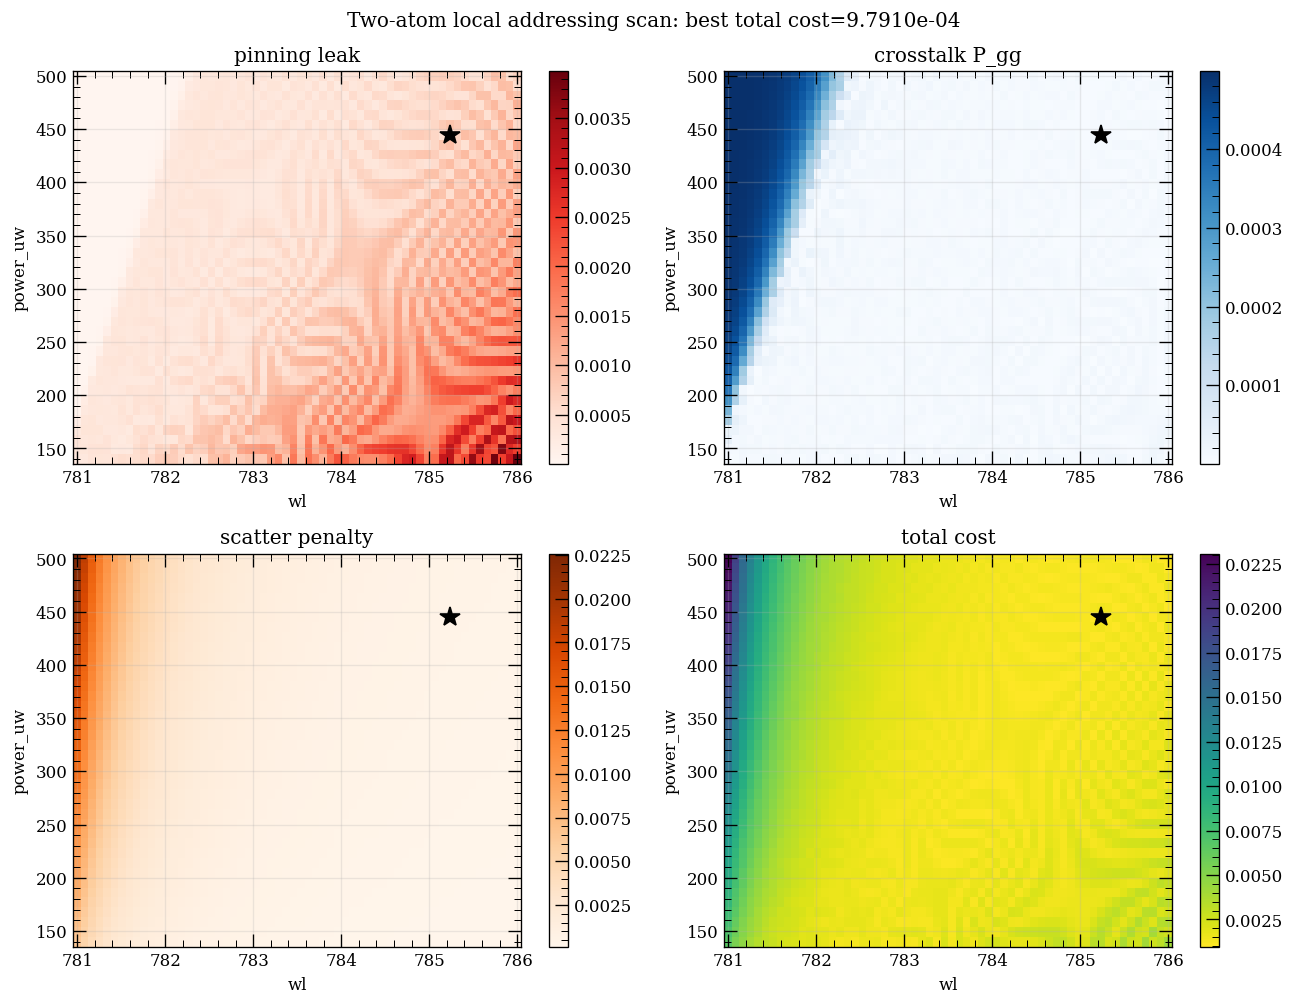

Best point: lambda `785.237` nm, power `444.6` uW, delta_A `-22.900` MHz, P_gr `0.99876`, total cost `9.79103e-04`.

In [11]:
grid_dir = REPO_ROOT / "results" / "ac_stark_addressing" / "optimization_grids"
candidates = [grid_dir / f"exp{i}_addressing_opt_grid.csv" for i in (5, 4, 3, 2, 1)]
scan_csv = next((p for p in candidates if p.exists()), None)

if scan_csv is None:
    print("No two-atom scan CSV found. Use the scan logic in this notebook or restore cached results before plotting.")
else:
    raw = np.loadtxt(scan_csv, delimiter=",", dtype=float)
    if raw.ndim == 1:
        raw = raw.reshape(1, -1)
    dtype_legacy = [
        ("wl", float), ("power_uw", float), ("delta_A_mhz", float), ("delta_B_mhz", float), ("scatter_A_hz", float),
        ("P_gg", float), ("P_gr", float), ("P_rg", float), ("P_rr", float), ("pinning_leak", float),
        ("crosstalk", float), ("scatter_penalty", float), ("total_cost", float), ("P_target", float), ("other_residual", float),
        ("delta_A_over_Omega", float), ("delta_A_over_V", float),
    ]
    dtype_new = dtype_legacy + [("delta_half_mhz", float), ("t_gate_us", float)]
    dtype = dtype_new if raw.shape[1] == 19 else dtype_legacy
    grid = np.empty(raw.shape[0], dtype=dtype)
    for i, name in enumerate(grid.dtype.names):
        grid[name] = raw[:, i]
    if raw.shape[1] == 17:
        new_grid = np.empty(len(grid), dtype=dtype_new)
        for name in grid.dtype.names:
            new_grid[name] = grid[name]
        new_grid["delta_half_mhz"] = 40.0
        new_grid["t_gate_us"] = 4.5
        grid = new_grid

    print(f"Loaded {scan_csv} with {len(grid)} points")
    best = grid[np.argmin(grid["total_cost"])]
    varying = [(name, np.unique(grid[name])) for name in ("wl", "power_uw", "delta_half_mhz", "t_gate_us") if len(np.unique(grid[name])) > 1]
    if len(varying) >= 2:
        x_name, x_vals = varying[0]
        y_name, y_vals = varying[1]
        fig, axes = plt.subplots(2, 2, figsize=(11, 8.5))
        for ax, field, title, cmap in zip(
            axes.flat,
            ["pinning_leak", "crosstalk", "scatter_penalty", "total_cost"],
            ["pinning leak", "crosstalk P_gg", "scatter penalty", "total cost"],
            ["Reds", "Blues", "Oranges", "viridis_r"],
        ):
            Z = np.full((len(y_vals), len(x_vals)), np.nan)
            for row in grid:
                ix = int(np.argmin(np.abs(x_vals - row[x_name])))
                iy = int(np.argmin(np.abs(y_vals - row[y_name])))
                Z[iy, ix] = row[field]
            im = ax.pcolormesh(x_vals, y_vals, Z, cmap=cmap, shading="auto")
            ax.plot(best[x_name], best[y_name], "k*", ms=12)
            ax.set_xlabel(x_name)
            ax.set_ylabel(y_name)
            ax.set_title(title)
            fig.colorbar(im, ax=ax)
        fig.suptitle(f"Two-atom local addressing scan: best total cost={best['total_cost']:.4e}")
        fig.tight_layout()
        plt.show()
    display(Markdown(
        f"Best point: lambda `{best['wl']:.3f}` nm, power `{best['power_uw']:.1f}` uW, "
        f"delta_A `{best['delta_A_mhz']:.3f}` MHz, P_gr `{best['P_gr']:.5f}`, total cost `{best['total_cost']:.5e}`."
    ))
